# SQL IN R ANALYSIS

I. Importing Dataset from github

In [2]:
#cloning github repository to retreive the dataset
system("git clone https://github.com/nomankaleemromane/NorthStar-DBA-Coursework.git")

II. Installing Libararies

In [3]:
#installing required packages
install.packages(c("DBI", "RSQLite", "sqldf", "dplyr", "ggplot2"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘chron’




In [4]:
#loading libraries
library(DBI)
library(RSQLite)
library(sqldf)
library(dplyr)
library(ggplot2)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




III. Reading csv files from github repo

In [5]:
# Read CSV files from github repo
customers <- read.csv("NorthStar-DBA-Coursework/customers.csv")
orders <- read.csv("NorthStar-DBA-Coursework/orders.csv")
deliveries <- read.csv("NorthStar-DBA-Coursework/deliveries.csv")
drivers <- read.csv("NorthStar-DBA-Coursework/drivers.csv")
vehicles <- read.csv("NorthStar-DBA-Coursework/vehicles.csv")
hubs <- read.csv("NorthStar-DBA-Coursework/hubs.csv")
complaints <- read.csv("NorthStar-DBA-Coursework/complaints.csv")
incidents <- read.csv("NorthStar-DBA-Coursework/incidents.csv")
app_events <- read.csv("NorthStar-DBA-Coursework/app_events.csv")
data_dictionary <- read.csv("NorthStar-DBA-Coursework/data_dictionary.csv")

IV. Create SQLite Database and Write Tables

In [6]:
# Create in-memory SQLite database
con <- dbConnect(SQLite(), ":memory:")

# Write each dataframe to a table
dbWriteTable(con, "customers", customers)
dbWriteTable(con, "orders", orders)
dbWriteTable(con, "deliveries", deliveries)
dbWriteTable(con, "drivers", drivers)
dbWriteTable(con, "vehicles", vehicles)
dbWriteTable(con, "hubs", hubs)
dbWriteTable(con, "complaints", complaints)
dbWriteTable(con, "incidents", incidents)
dbWriteTable(con, "app_events", app_events)
dbWriteTable(con, "data_dictionary", data_dictionary)
# Verify tables are created
dbListTables(con)

[1] "app_events"      "complaints"      "customers"       "data_dictionary"
 [5] "deliveries"      "drivers"         "hubs"            "incidents"      
 [9] "orders"          "vehicles"

V. Basic SQL Operations (CRUD)

1. SELECT - View customer records

In [7]:
dbGetQuery(con, "SELECT * FROM customers LIMIT 5")

customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,,Active
C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


2. INSERT - Add a new customer record

In [8]:
dbExecute(con, "INSERT INTO customers (customer_id, age, home_zone, customer_type, signup_date, loyalty_score, app_engagement_score, preferred_channel, account_status)
          VALUES ('C0651', 34, 'North', 'Consumer', '2025-06-01', 75.5, 80.2, 'App', 'Active')")

[1] 1

3. UPDATE — Correct a delivery status:

In [9]:
dbExecute(con, "UPDATE deliveries SET delivery_status = 'Delayed' WHERE delivery_id = 'DL00060'")

[1] 1

4. DELETE — Remove the test customer

In [10]:
dbExecute(con, "DELETE FROM customers WHERE customer_id = 'C0651'")

[1] 1

II. Data Cleaning in R

step 1: Standardize zone names

In [11]:
dbExecute(con, "UPDATE customers SET home_zone = 'North' WHERE LOWER(home_zone) = 'north'")
dbExecute(con, "UPDATE customers SET home_zone = 'South' WHERE LOWER(home_zone) = 'south'")
dbExecute(con, "UPDATE customers SET home_zone = 'East' WHERE LOWER(home_zone) = 'east'")
dbExecute(con, "UPDATE customers SET home_zone = 'West' WHERE LOWER(home_zone) = 'west'")
dbExecute(con, "UPDATE customers SET home_zone = 'Central' WHERE LOWER(home_zone) IN ('central', 'ctr')")
dbExecute(con, "UPDATE customers SET home_zone = 'Airport' WHERE LOWER(home_zone) = 'airport'")
dbExecute(con, "UPDATE customers SET home_zone = 'Riverside' WHERE LOWER(home_zone) IN ('riverside', 'riverside')")

[1] 111

[1] 92

[1] 89

[1] 88

[1] 110

[1] 69

[1] 91

In [12]:
dbExecute(con, "UPDATE drivers SET base_zone = 'North' WHERE LOWER(base_zone) = 'north'")
dbExecute(con, "UPDATE drivers SET base_zone = 'South' WHERE LOWER(base_zone) = 'south'")
dbExecute(con, "UPDATE drivers SET base_zone = 'East' WHERE LOWER(base_zone) = 'east'")
dbExecute(con, "UPDATE drivers SET base_zone = 'West' WHERE LOWER(base_zone) = 'west'")
dbExecute(con, "UPDATE drivers SET base_zone = 'Central' WHERE LOWER(base_zone) IN ('central', 'ctr')")
dbExecute(con, "UPDATE drivers SET base_zone = 'Airport' WHERE LOWER(base_zone) = 'airport'")
dbExecute(con, "UPDATE drivers SET base_zone = 'Riverside' WHERE LOWER(base_zone) IN ('riverside', 'riverside')")

[1] 36

[1] 29

[1] 21

[1] 20

[1] 28

[1] 19

[1] 17

In [13]:
dbExecute(con, "UPDATE orders SET pickup_zone = 'North' WHERE LOWER(pickup_zone) = 'north'")
dbExecute(con, "UPDATE orders SET pickup_zone = 'South' WHERE LOWER(pickup_zone) = 'south'")
dbExecute(con, "UPDATE orders SET pickup_zone = 'East' WHERE LOWER(pickup_zone) = 'east'")
dbExecute(con, "UPDATE orders SET pickup_zone = 'West' WHERE LOWER(pickup_zone) = 'west'")
dbExecute(con, "UPDATE orders SET pickup_zone = 'Central' WHERE LOWER(pickup_zone) IN ('central', 'ctr')")
dbExecute(con, "UPDATE orders SET pickup_zone = 'Airport' WHERE LOWER(pickup_zone) = 'airport'")
dbExecute(con, "UPDATE orders SET pickup_zone = 'Riverside' WHERE LOWER(pickup_zone) IN ('riverside', 'riverside')")

[1] 174

[1] 181

[1] 207

[1] 155

[1] 238

[1] 144

[1] 151

In [14]:
dbExecute(con, "UPDATE orders SET dropoff_zone = 'North' WHERE LOWER(dropoff_zone) = 'north'")
dbExecute(con, "UPDATE orders SET dropoff_zone = 'South' WHERE LOWER(dropoff_zone) = 'south'")
dbExecute(con, "UPDATE orders SET dropoff_zone = 'East' WHERE LOWER(dropoff_zone) = 'east'")
dbExecute(con, "UPDATE orders SET dropoff_zone = 'West' WHERE LOWER(dropoff_zone) = 'west'")
dbExecute(con, "UPDATE orders SET dropoff_zone = 'Central' WHERE LOWER(dropoff_zone) IN ('central', 'ctr')")
dbExecute(con, "UPDATE orders SET dropoff_zone = 'Airport' WHERE LOWER(dropoff_zone) = 'airport'")
dbExecute(con, "UPDATE orders SET dropoff_zone = 'Riverside' WHERE LOWER(dropoff_zone) IN ('riverside', 'riverside')")

[1] 191

[1] 178

[1] 155

[1] 197

[1] 185

[1] 163

[1] 181

In [15]:
dbExecute(con, "UPDATE hubs SET zone = 'North' WHERE LOWER(zone) = 'north'")
dbExecute(con, "UPDATE hubs SET zone = 'South' WHERE LOWER(zone) = 'south'")
dbExecute(con, "UPDATE hubs SET zone = 'East' WHERE LOWER(zone) = 'east'")
dbExecute(con, "UPDATE hubs SET zone = 'West' WHERE LOWER(zone) = 'west'")
dbExecute(con, "UPDATE hubs SET zone = 'Central' WHERE LOWER(zone) IN ('central', 'ctr')")
dbExecute(con, "UPDATE hubs SET zone = 'Airport' WHERE LOWER(zone) = 'airport'")
dbExecute(con, "UPDATE hubs SET zone = 'Riverside' WHERE LOWER(zone) IN ('riverside', 'riverside')")

[1] 1

[1] 1

[1] 1

[1] 1

[1] 2

[1] 1

[1] 1

In [16]:
dbExecute(con, "UPDATE app_events SET zone_context = 'North' WHERE LOWER(zone_context) = 'north'")
dbExecute(con, "UPDATE app_events SET zone_context = 'South' WHERE LOWER(zone_context) = 'south'")
dbExecute(con, "UPDATE app_events SET zone_context = 'East' WHERE LOWER(zone_context) = 'east'")
dbExecute(con, "UPDATE app_events SET zone_context = 'West' WHERE LOWER(zone_context) = 'west'")
dbExecute(con, "UPDATE app_events SET zone_context = 'Central' WHERE LOWER(zone_context) IN ('central', 'ctr')")
dbExecute(con, "UPDATE app_events SET zone_context = 'Airport' WHERE LOWER(zone_context) = 'airport'")
dbExecute(con, "UPDATE app_events SET zone_context = 'Riverside' WHERE LOWER(zone_context) IN ('riverside', 'riverside')")

[1] 93

[1] 95

[1] 91

[1] 94

[1] 93

[1] 87

[1] 87

In [17]:
# Verify standardised zones across all tables
dbGetQuery(con, "SELECT DISTINCT home_zone FROM customers ORDER BY home_zone")
dbGetQuery(con, "SELECT DISTINCT base_zone FROM drivers ORDER BY base_zone")
dbGetQuery(con, "SELECT DISTINCT pickup_zone FROM orders ORDER BY pickup_zone")
dbGetQuery(con, "SELECT DISTINCT dropoff_zone FROM orders ORDER BY dropoff_zone")
dbGetQuery(con, "SELECT DISTINCT zone FROM hubs ORDER BY zone")
dbGetQuery(con, "SELECT DISTINCT zone_context FROM app_events ORDER BY zone_context")

home_zone
<chr>
Airport
Central
East
North
Riverside
South
West


base_zone
<chr>
Airport
Central
East
North
Riverside
South
West


pickup_zone
<chr>
Airport
Central
East
North
Riverside
South
West


dropoff_zone
<chr>
Airport
Central
East
North
Riverside
South
West


zone
<chr>
Airport
Central
East
North
Riverside
South
West


zone_context
<chr>
Airport
Central
East
North
Riverside
South
West


Step 2: Counting Missing values in tables

In [18]:
# Count missing values in customers table
dbGetQuery(con, "
  SELECT
    SUM(CASE WHEN age IS NULL THEN 1 ELSE 0 END) AS missing_age,
    SUM(CASE WHEN loyalty_score IS NULL THEN 1 ELSE 0 END) AS missing_loyalty,
    SUM(CASE WHEN app_engagement_score IS NULL THEN 1 ELSE 0 END) AS missing_engagement,
    SUM(CASE WHEN preferred_channel IS NULL OR preferred_channel = '' THEN 1 ELSE 0 END) AS missing_channel
  FROM customers
")

missing_age,missing_loyalty,missing_engagement,missing_channel
<int>,<int>,<int>,<int>
0,20,0,13


In [19]:
# orders table
dbGetQuery(con, "
  SELECT
    SUM(CASE WHEN service_type IS NULL THEN 1 ELSE 0 END) AS missing_service_type,
    SUM(CASE WHEN priority_level IS NULL THEN 1 ELSE 0 END) AS missing_priority,
    SUM(CASE WHEN booking_channel IS NULL OR booking_channel = '' THEN 1 ELSE 0 END) AS missing_channel
  FROM orders
")

missing_service_type,missing_priority,missing_channel
<int>,<int>,<int>
0,0,25


In [20]:
# deliveries table
dbGetQuery(con, "
  SELECT
    SUM(CASE WHEN delivery_completed_at IS NULL OR delivery_completed_at = '' THEN 1 ELSE 0 END) AS missing_completion_time,
    SUM(CASE WHEN customer_rating_post_delivery IS NULL OR customer_rating_post_delivery = '' THEN 1 ELSE 0 END) AS missing_rating,
    SUM(CASE WHEN fuel_or_charge_cost IS NULL OR fuel_or_charge_cost = '' THEN 1 ELSE 0 END) AS missing_cost
  FROM deliveries
")

missing_completion_time,missing_rating,missing_cost
<int>,<int>,<int>
19,14,0


In [21]:
# drivers table
dbGetQuery(con, "
  SELECT
    SUM(CASE WHEN training_score IS NULL THEN 1 ELSE 0 END) AS missing_training,
    SUM(CASE WHEN driver_rating IS NULL THEN 1 ELSE 0 END) AS missing_rating,
    SUM(CASE WHEN shift_preference IS NULL OR shift_preference = '' THEN 1 ELSE 0 END) AS missing_shift
  FROM drivers
")

missing_training,missing_rating,missing_shift
<int>,<int>,<int>
7,0,0


In [22]:
# vehicles table
dbGetQuery(con, "
  SELECT
    SUM(CASE WHEN battery_health_pct IS NULL OR battery_health_pct = '' THEN 1 ELSE 0 END) AS missing_battery,
    SUM(CASE WHEN maintenance_status IS NULL OR maintenance_status = '' THEN 1 ELSE 0 END) AS missing_status,
    SUM(CASE WHEN telematics_version IS NULL OR telematics_version = '' THEN 1 ELSE 0 END) AS missing_telematics
  FROM vehicles
")

missing_battery,missing_status,missing_telematics
<int>,<int>,<int>
4,0,0


In [23]:
# hubs table
dbGetQuery(con, "
  SELECT
    SUM(CASE WHEN hub_name IS NULL OR hub_name = '' THEN 1 ELSE 0 END) AS missing_name,
    SUM(CASE WHEN zone IS NULL OR zone = '' THEN 1 ELSE 0 END) AS missing_zone,
    SUM(CASE WHEN hub_type IS NULL OR hub_type = '' THEN 1 ELSE 0 END) AS missing_type,
    SUM(CASE WHEN capacity_score IS NULL THEN 1 ELSE 0 END) AS missing_capacity
  FROM hubs
")

missing_name,missing_zone,missing_type,missing_capacity
<int>,<int>,<int>,<int>
0,0,0,0


In [24]:
# complaints table
dbGetQuery(con, "
  SELECT
    SUM(CASE WHEN complaint_type IS NULL OR complaint_type = '' THEN 1 ELSE 0 END) AS missing_type,
    SUM(CASE WHEN severity IS NULL OR severity = '' THEN 1 ELSE 0 END) AS missing_severity,
    SUM(CASE WHEN compensation_amount IS NULL OR compensation_amount = '' THEN 1 ELSE 0 END) AS missing_compensation,
    SUM(CASE WHEN resolution_days IS NULL THEN 1 ELSE 0 END) AS missing_resolution
  FROM complaints
")

missing_type,missing_severity,missing_compensation,missing_resolution
<int>,<int>,<int>,<int>
0,0,16,0


In [25]:
# incidents table
dbGetQuery(con, "
  SELECT
    SUM(CASE WHEN incident_type IS NULL OR incident_type = '' THEN 1 ELSE 0 END) AS missing_type,
    SUM(CASE WHEN severity IS NULL OR severity = '' THEN 1 ELSE 0 END) AS missing_severity,
    SUM(CASE WHEN resolution_status IS NULL OR resolution_status = '' THEN 1 ELSE 0 END) AS missing_status,
    SUM(CASE WHEN resolved_hours IS NULL THEN 1 ELSE 0 END) AS missing_hours
  FROM incidents
")

missing_type,missing_severity,missing_status,missing_hours
<int>,<int>,<int>,<int>
0,0,0,17


In [26]:
# app_events table
dbGetQuery(con, "
  SELECT
    SUM(CASE WHEN event_type IS NULL OR event_type = '' THEN 1 ELSE 0 END) AS missing_event_type,
    SUM(CASE WHEN device_type IS NULL OR device_type = '' THEN 1 ELSE 0 END) AS missing_device,
    SUM(CASE WHEN zone_context IS NULL OR zone_context = '' THEN 1 ELSE 0 END) AS missing_zone,
    SUM(CASE WHEN api_latency_ms IS NULL THEN 1 ELSE 0 END) AS missing_latency,
    SUM(CASE WHEN success_flag IS NULL THEN 1 ELSE 0 END) AS missing_success
  FROM app_events
")

missing_event_type,missing_device,missing_zone,missing_latency,missing_success
<int>,<int>,<int>,<int>,<int>
0,0,0,0,0


In [27]:
# data_dictionary table
dbGetQuery(con, "
  SELECT
    SUM(CASE WHEN file_name IS NULL OR file_name = '' THEN 1 ELSE 0 END) AS missing_filename,
    SUM(CASE WHEN record_count IS NULL THEN 1 ELSE 0 END) AS missing_count,
    SUM(CASE WHEN description IS NULL OR description = '' THEN 1 ELSE 0 END) AS missing_description
  FROM data_dictionary
")

missing_filename,missing_count,missing_description
<int>,<int>,<int>
0,0,0


Convert empty strings to NULL across all tables

In [28]:
# Convert empty strings to NULL across all tables
dbExecute(con, "UPDATE customers SET preferred_channel = NULL WHERE preferred_channel = ''")
dbExecute(con, "UPDATE orders SET booking_channel = NULL WHERE booking_channel = ''")
dbExecute(con, "UPDATE deliveries SET delivery_completed_at = NULL WHERE delivery_completed_at = ''")
dbExecute(con, "UPDATE deliveries SET customer_rating_post_delivery = NULL WHERE customer_rating_post_delivery = ''")
dbExecute(con, "UPDATE deliveries SET fuel_or_charge_cost = NULL WHERE fuel_or_charge_cost = ''")
dbExecute(con, "UPDATE drivers SET shift_preference = NULL WHERE shift_preference = ''")
dbExecute(con, "UPDATE vehicles SET battery_health_pct = NULL WHERE battery_health_pct = ''")
dbExecute(con, "UPDATE vehicles SET maintenance_status = NULL WHERE maintenance_status = ''")
dbExecute(con, "UPDATE vehicles SET telematics_version = NULL WHERE telematics_version = ''")
dbExecute(con, "UPDATE hubs SET hub_name = NULL WHERE hub_name = ''")
dbExecute(con, "UPDATE hubs SET zone = NULL WHERE zone = ''")
dbExecute(con, "UPDATE hubs SET hub_type = NULL WHERE hub_type = ''")
dbExecute(con, "UPDATE complaints SET complaint_type = NULL WHERE complaint_type = ''")
dbExecute(con, "UPDATE complaints SET severity = NULL WHERE severity = ''")
dbExecute(con, "UPDATE complaints SET compensation_amount = NULL WHERE compensation_amount = ''")
dbExecute(con, "UPDATE incidents SET incident_type = NULL WHERE incident_type = ''")
dbExecute(con, "UPDATE incidents SET severity = NULL WHERE severity = ''")
dbExecute(con, "UPDATE incidents SET resolution_status = NULL WHERE resolution_status = ''")
dbExecute(con, "UPDATE app_events SET event_type = NULL WHERE event_type = ''")
dbExecute(con, "UPDATE app_events SET device_type = NULL WHERE device_type = ''")
dbExecute(con, "UPDATE app_events SET zone_context = NULL WHERE zone_context = ''")
dbExecute(con, "UPDATE data_dictionary SET file_name = NULL WHERE file_name = ''")
dbExecute(con, "UPDATE data_dictionary SET description = NULL WHERE description = ''")

[1] 13

[1] 25

[1] 19

[1] 0

[1] 0

...

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

Step 3: Convert Date Columns to Proper Format

In [29]:
# Convert date columns from character strings to proper datetime format
# This allows time-based calculations like delivery duration and monthly trends
customers$signup_date <- as.POSIXct(customers$signup_date, format = "%Y-%m-%d %H:%M:%S")
orders$order_created_at <- as.POSIXct(orders$order_created_at, format = "%Y-%m-%d %H:%M:%S")
deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time, format = "%Y-%m-%d %H:%M:%S")
deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at, format = "%Y-%m-%d %H:%M:%OS", optional = TRUE)
complaints$created_at <- as.POSIXct(complaints$created_at, format = "%Y-%m-%d %H:%M:%S")
incidents$reported_at <- as.POSIXct(incidents$reported_at, format = "%Y-%m-%d %H:%M:%S")
app_events$event_timestamp <- as.POSIXct(app_events$event_timestamp, format = "%Y-%m-%d %H:%M:%S")

In [30]:
# Overwrite tables in SQLite with cleaned data
# This ensures the database contains standardised zones, proper NULLs, and correct datetime formats
dbWriteTable(con, "customers", customers, overwrite = TRUE)
dbWriteTable(con, "orders", orders, overwrite = TRUE)
dbWriteTable(con, "deliveries", deliveries, overwrite = TRUE)
dbWriteTable(con, "drivers", drivers, overwrite = TRUE)
dbWriteTable(con, "vehicles", vehicles, overwrite = TRUE)
dbWriteTable(con, "hubs", hubs, overwrite = TRUE)
dbWriteTable(con, "complaints", complaints, overwrite = TRUE)
dbWriteTable(con, "incidents", incidents, overwrite = TRUE)
dbWriteTable(con, "app_events", app_events, overwrite = TRUE)
dbWriteTable(con, "data_dictionary", data_dictionary, overwrite = TRUE)

# Verify tables are updated
dbListTables(con)

[1] "app_events"      "complaints"      "customers"       "data_dictionary"
 [5] "deliveries"      "drivers"         "hubs"            "incidents"      
 [9] "orders"          "vehicles"

II. Mathematical and Aggregate Functions

1. Order Value Summary by Service Type



In [31]:
dbGetQuery(con, "
  SELECT
    COUNT(*) AS total_deliveries,
    ROUND(AVG(route_distance_km), 2) AS avg_distance_km,
    ROUND(AVG(fuel_or_charge_cost), 2) AS avg_cost,
    MIN(route_distance_km) AS min_distance,
    MAX(route_distance_km) AS max_distance,
    ROUND(SUM(CASE WHEN delivery_status = 'OnTime' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS ontime_pct,
    ROUND(SUM(CASE WHEN delivery_status = 'Delayed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS delayed_pct,
    ROUND(SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failed_pct
  FROM deliveries
")

total_deliveries,avg_distance_km,avg_cost,min_distance,max_distance,ontime_pct,delayed_pct,failed_pct
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
950,13.91,12.84,1.2,41.94,64.84,21.26,13.89


2. Order Value Summary by Service Type

In [32]:
dbGetQuery(con, "
  SELECT
    service_type,
    COUNT(*) AS total_orders,
    ROUND(AVG(order_value), 2) AS avg_value,
    MIN(order_value) AS min_value,
    MAX(order_value) AS max_value,
    ROUND(SUM(order_value), 2) AS total_revenue
  FROM orders
  GROUP BY service_type
  ORDER BY total_revenue DESC
")

service_type,total_orders,avg_value,min_value,max_value,total_revenue
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Passenger,341,96.07,5.92,326.38,32761.11
Parcel,308,87.62,3.57,510.06,26985.62
Retail,297,90.01,4.22,355.62,26734.06
Business,165,92.25,6.28,321.68,15220.43
Medical,139,87.14,2.04,292.33,12111.93


3. Driver Rating Summary by Employment Type



In [33]:
dbGetQuery(con, "
  SELECT
    employment_type,
    COUNT(*) AS driver_count,
    ROUND(AVG(driver_rating), 2) AS avg_rating,
    ROUND(AVG(years_experience), 1) AS avg_experience,
    ROUND(AVG(training_score), 1) AS avg_training
  FROM drivers
  GROUP BY employment_type
  ORDER BY avg_rating DESC
")

employment_type,driver_count,avg_rating,avg_experience,avg_training
<chr>,<int>,<dbl>,<dbl>,<dbl>
PartTime,40,4.22,8.1,73.6
FullTime,110,4.17,8.3,75.6
Contract,20,4.09,8.0,73.3


4. Complaint Summary by Severity



In [34]:
  dbGetQuery(con, "
  SELECT
    severity,
    COUNT(*) AS complaint_count,
    ROUND(AVG(resolution_days), 1) AS avg_resolution_days,
    ROUND(AVG(compensation_amount), 2) AS avg_compensation
  FROM complaints
  GROUP BY severity
  ORDER BY complaint_count DESC
")

severity,complaint_count,avg_resolution_days,avg_compensation
<chr>,<int>,<dbl>,<dbl>
Medium,172,6.2,17.37
High,77,13.1,38.85
Low,71,6.6,9.06


5. Vehicle Fleet Summary by Type

In [35]:
dbGetQuery(con, "
  SELECT
    vehicle_type,
    COUNT(*) AS fleet_count,
    ROUND(AVG(battery_health_pct), 1) AS avg_battery_health,
    ROUND(AVG(odometer_km), 0) AS avg_odometer,
    SUM(CASE WHEN maintenance_status = 'InRepair' THEN 1 ELSE 0 END) AS in_repair,
    SUM(CASE WHEN maintenance_status = 'Scheduled' THEN 1 ELSE 0 END) AS scheduled
  FROM vehicles
  GROUP BY vehicle_type
  ORDER BY fleet_count DESC
")

vehicle_type,fleet_count,avg_battery_health,avg_odometer,in_repair,scheduled
<chr>,<int>,<dbl>,<dbl>,<int>,<int>
EV,43,82.1,126150,8,6
CargoVan,30,73.4,112864,12,4
Hybrid,28,76.8,120745,9,5
Diesel,19,70.6,89343,7,2


III. Analytical Queries with Business Interpretation

Query 1: Delivery Failure Rates by City Zone

---


Case study question: "Why do some city zones consistently perform worse than others?"

In [43]:
zone_performance <- dbGetQuery(con, "
  SELECT
    h.zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
    ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(d.delivery_id), 2) AS failure_rate_pct,
    ROUND(SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) * 100.0 / COUNT(d.delivery_id), 2) AS delay_rate_pct,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.zone
  ORDER BY failure_rate_pct DESC
")
print(zone_performance)

       zone total_deliveries failed failure_rate_pct delay_rate_pct
1   Central              243     49            20.16          19.34
2   Airport              104     15            14.42          25.96
3      West              127     16            12.60          22.05
4     North              136     17            12.50          19.12
5 Riverside              115     14            12.17          21.74
6     South              106     10             9.43          24.53
7      East              119     11             9.24          19.33
  avg_overrides avg_cost
1          1.03    12.64
2          0.91    13.32
3          0.87    13.17
4          1.03    12.76
5          1.05    12.92
6          0.92    12.57
7          0.89    12.74


Visualisation

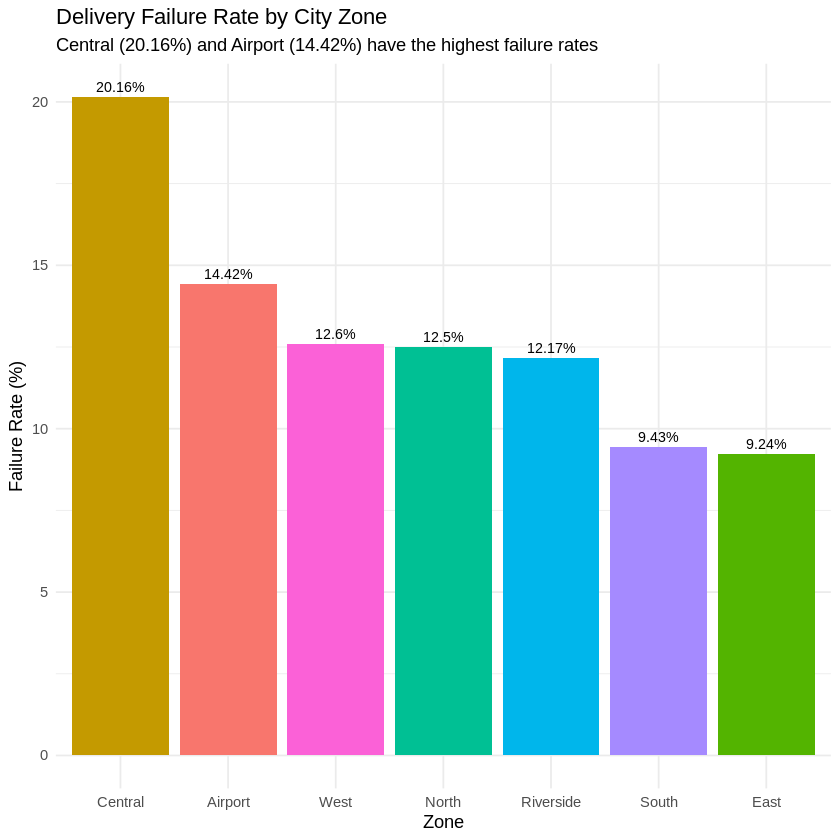

In [45]:
library(ggplot2)

# Get top 2 zones for the subtitle
top_zones <- head(zone_performance[order(-zone_performance$failure_rate_pct), ], 2)
subtitle_text <- paste0(top_zones$zone[1], " (", top_zones$failure_rate_pct[1], "%) and ",
                        top_zones$zone[2], " (", top_zones$failure_rate_pct[2], "%) have the highest failure rates")

ggplot(zone_performance, aes(x = reorder(zone, -failure_rate_pct), y = failure_rate_pct, fill = zone)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(failure_rate_pct, "%")), vjust = -0.5, size = 3) +
  labs(title = "Delivery Failure Rate by City Zone",
       subtitle = subtitle_text,
       x = "Zone",
       y = "Failure Rate (%)") +
  theme_minimal() +
  theme(legend.position = "none")

Query 2: Manual Route Overrides vs Delivery Outcomes

---


Case study question: "Is this genuine road conditions, poor planning, or drivers avoiding performance targets?"

In [58]:
override_analysis <- dbGetQuery(con, "
  SELECT
    CASE
      WHEN manual_route_override_count = 0 THEN '1. None'
      WHEN manual_route_override_count = 1 THEN '2. 1 Override'
      WHEN manual_route_override_count BETWEEN 2 AND 3 THEN '3. 2-3 Overrides'
      ELSE '4. 4+ Overrides'
    END AS override_group,
    COUNT(*) AS deliveries,
    ROUND(SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_pct,
    ROUND(SUM(CASE WHEN delivery_status = 'Delayed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS delay_pct,
    ROUND(SUM(CASE WHEN delivery_status = 'OnTime' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS ontime_pct,
    ROUND(AVG(fuel_or_charge_cost), 2) AS avg_cost
  FROM deliveries
  GROUP BY override_group
  ORDER BY override_group
")
print(override_analysis)

    override_group deliveries failure_pct delay_pct ontime_pct avg_cost
1          1. None        399       11.53     19.55      68.92    12.43
2    2. 1 Override        310       16.45     21.61      61.94    12.88
3 3. 2-3 Overrides        210       15.24     22.86      61.90    13.45
4  4. 4+ Overrides         31        9.68     29.03      61.29    13.62


visualisation

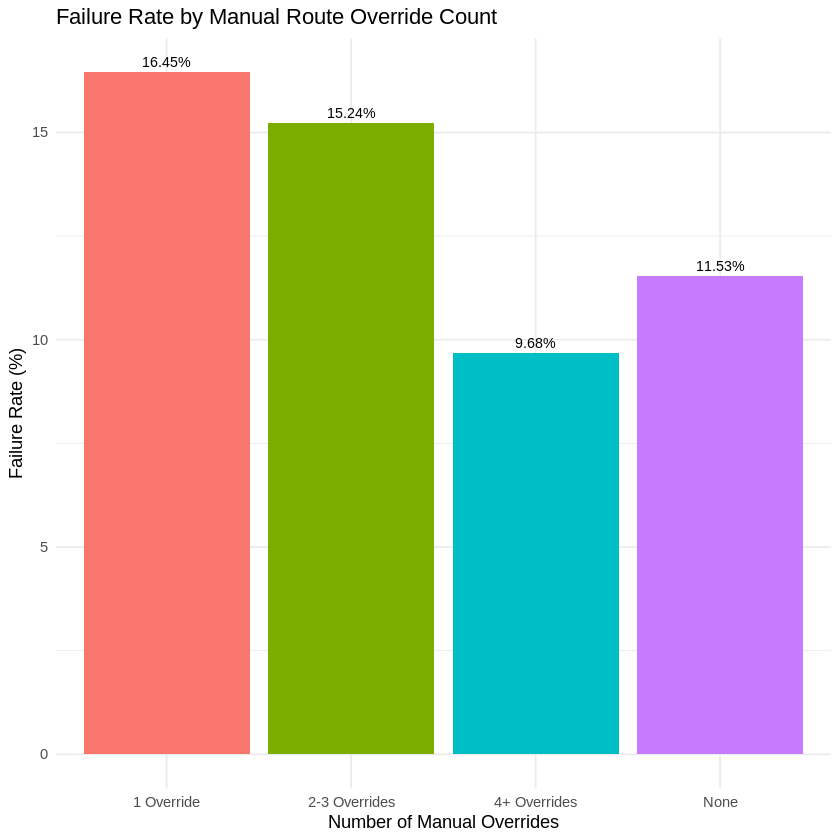

In [48]:
ggplot(override_analysis, aes(x = override_group, y = failure_pct, fill = override_group)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(failure_pct, "%")), vjust = -0.5, size = 3) +
  labs(title = "Failure Rate by Manual Route Override Count",
       x = "Number of Manual Overrides",
       y = "Failure Rate (%)") +
  theme_minimal() +
  theme(legend.position = "none")

Query 3: Driver Performance — Bottom 10 by On-Time Rate

---


Case study question: "Which factors drive failure and customer dissatisfaction?"

In [59]:
driver_performance <- dbGetQuery(con, "
  SELECT
    dr.driver_id,
    dr.base_zone,
    dr.employment_type,
    dr.years_experience,
    dr.training_score,
    COUNT(dl.delivery_id) AS total_deliveries,
    ROUND(SUM(CASE WHEN dl.delivery_status = 'OnTime' THEN 1 ELSE 0 END) * 100.0 / COUNT(dl.delivery_id), 2) AS on_time_pct,
    ROUND(AVG(dl.manual_route_override_count), 2) AS avg_overrides,
    ROUND(AVG(dl.fuel_or_charge_cost), 2) AS avg_cost
  FROM drivers dr
  JOIN deliveries dl ON dr.driver_id = dl.driver_id
  GROUP BY dr.driver_id
  HAVING COUNT(dl.delivery_id) >= 5
  ORDER BY on_time_pct ASC
  LIMIT 10
")
print(driver_performance)

   driver_id base_zone employment_type years_experience training_score
1       D100   CENTRAL        FullTime                4           62.0
2       D053      West        FullTime                5           83.3
3       D023      EAST        FullTime               11           79.1
4       D141     North        PartTime               14           71.4
5       D165     North        PartTime               10           82.2
6       D005     north        FullTime                3           69.7
7       D092      East        FullTime               15           88.2
8       D094       Ctr        PartTime                6           60.8
9       D095      WEST        FullTime               12           99.0
10      D156     South        FullTime               14           84.5
   total_deliveries on_time_pct avg_overrides avg_cost
1                 8       25.00          1.25    16.27
2                 7       28.57          0.86    12.29
3                 6       33.33          0.33    14.54

Visualisation

`geom_smooth()` using formula = 'y ~ x'


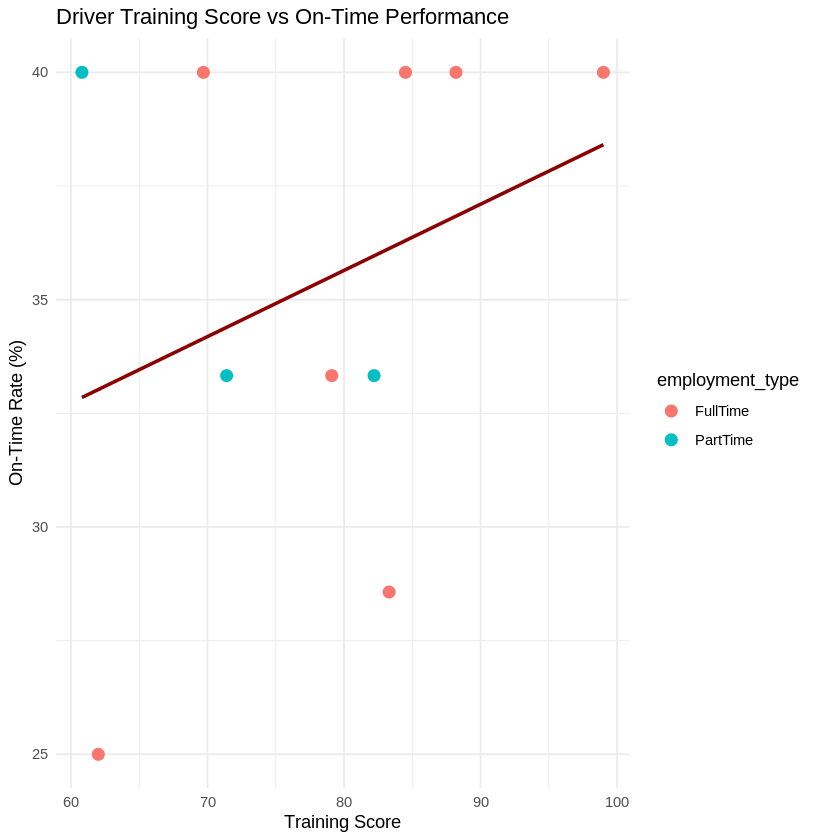

In [67]:
ggplot(driver_performance, aes(x = training_score, y = on_time_pct)) +
  geom_point(aes(color = employment_type), size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "darkred") +
  labs(title = "Driver Training Score vs On-Time Performance",
       x = "Training Score",
       y = "On-Time Rate (%)") +
  theme_minimal()

Query 4: Complaints Linked to Delivery Outcomes

---


Case study question: "Why does service reliability fall when complaints, missed journeys, and failed deliveries are not connected?"

In [65]:
complaint_delivery_link <- dbGetQuery(con, "
  SELECT
    c.complaint_type,
    COUNT(c.complaint_id) AS complaint_count,
    ROUND(AVG(c.resolution_days), 1) AS avg_resolution_days,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation,
    ROUND(AVG(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100, 2) AS pct_failed_delivery,
    ROUND(AVG(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) * 100, 2) AS pct_delayed_delivery
  FROM complaints c
  LEFT JOIN deliveries d ON c.order_id = d.order_id
  GROUP BY c.complaint_type
  ORDER BY complaint_count DESC
")
print(complaint_delivery_link)

     complaint_type complaint_count avg_resolution_days avg_compensation
1             Delay             101                 7.3            18.05
2      MissedPickup              64                 7.6            22.59
3          AppIssue              53                 8.6            19.61
4   DriverBehaviour              51                 8.2            21.15
5 SupportExperience              20                 7.5            17.13
6           Billing              16                 7.8            23.87
7            Damage              15                11.3            23.98
  pct_failed_delivery pct_delayed_delivery
1                9.90                18.81
2               12.50                17.19
3                9.43                13.21
4                7.84                 9.80
5               20.00                10.00
6               12.50                18.75
7               13.33                 6.67


Visualisation

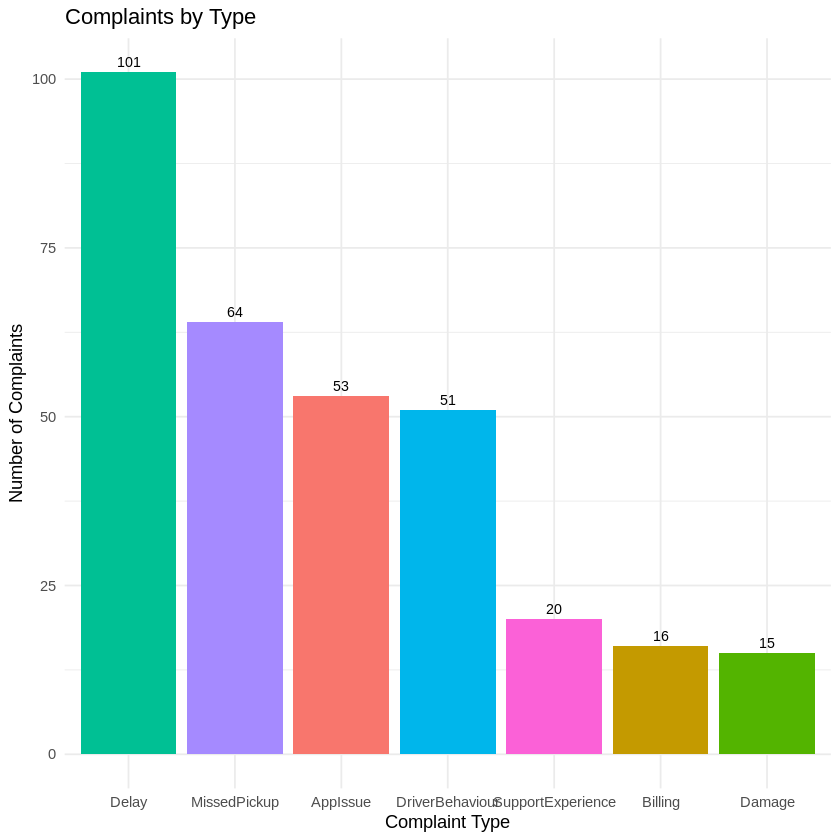

In [68]:
ggplot(complaint_delivery_link, aes(x = reorder(complaint_type, -complaint_count), y = complaint_count, fill = complaint_type)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = complaint_count), vjust = -0.5, size = 3) +
  labs(title = "Complaints by Type",
       x = "Complaint Type",
       y = "Number of Complaints") +
  theme_minimal() +
  theme(legend.position = "none")

In [69]:
vehicle_issues <- dbGetQuery(con, "
  SELECT
    v.vehicle_type,
    COUNT(DISTINCT v.vehicle_id) AS fleet_size,
    COUNT(i.incident_id) AS total_incidents,
    ROUND(COUNT(i.incident_id) * 1.0 / COUNT(DISTINCT v.vehicle_id), 2) AS incidents_per_vehicle,
    ROUND(AVG(i.resolved_hours), 1) AS avg_resolution_hours,
    SUM(CASE WHEN i.severity = 'Critical' THEN 1 ELSE 0 END) AS critical_incidents
  FROM vehicles v
  LEFT JOIN deliveries d ON v.vehicle_id = d.vehicle_id
  LEFT JOIN incidents i ON d.delivery_id = i.delivery_id
  GROUP BY v.vehicle_type
  ORDER BY incidents_per_vehicle DESC
")
print(vehicle_issues)

  vehicle_type fleet_size total_incidents incidents_per_vehicle
1       Diesel         19              47                  2.47
2       Hybrid         28              66                  2.36
3           EV         43             100                  2.33
4     CargoVan         30              67                  2.23
  avg_resolution_hours critical_incidents
1                 11.4                  6
2                 11.4                  6
3                 11.9                  9
4                 13.1                  6


Visualisation

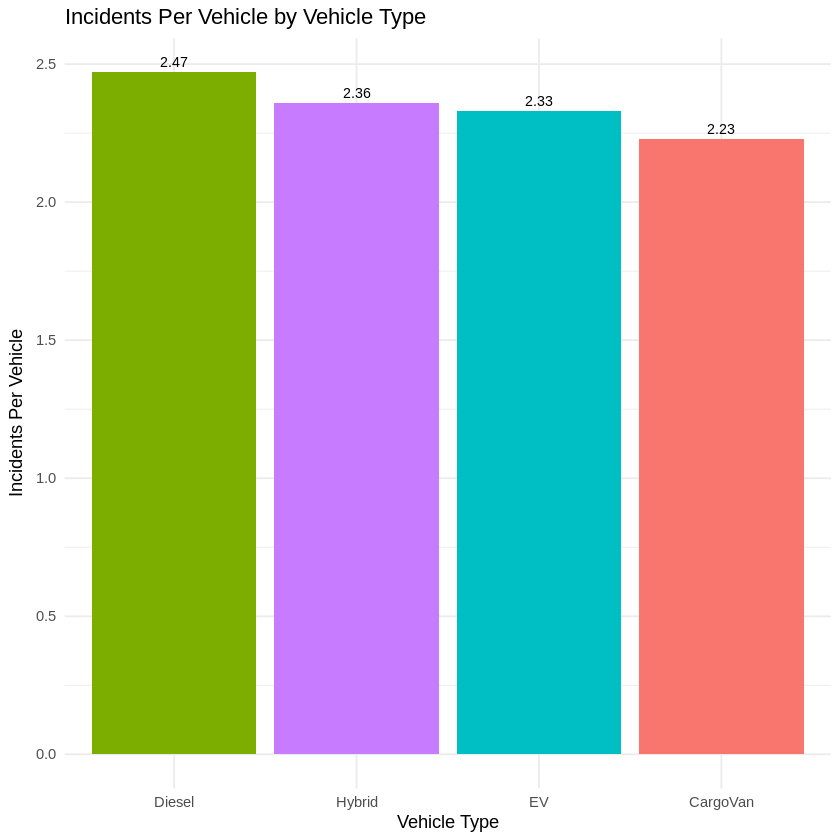

In [70]:
ggplot(vehicle_issues, aes(x = reorder(vehicle_type, -incidents_per_vehicle), y = incidents_per_vehicle, fill = vehicle_type)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = incidents_per_vehicle), vjust = -0.5, size = 3) +
  labs(title = "Incidents Per Vehicle by Vehicle Type",
       x = "Vehicle Type",
       y = "Incidents Per Vehicle") +
  theme_minimal() +
  theme(legend.position = "none")

IV. Data Manipulation and Transformation in R

Create Integrated Dataset

In [71]:
library(dplyr)

integrated_data <- orders %>%
  left_join(deliveries, by = "order_id") %>%
  left_join(customers, by = "customer_id") %>%
  left_join(complaints, by = "order_id")

glimpse(integrated_data)

Rows: 1,285
Columns: 40
$ order_id                      <chr> "O00001", "O00002", "O00003", "O00004", …
$ customer_id.x                 <chr> "C0292", "C0459", "C0161", "C0520", "C05…
$ service_type                  <chr> "Passenger", "Passenger", "Passenger", "…
$ order_created_at              <dttm> 2024-08-20 14:43:00, 2024-05-14 22:16:0…
$ promised_window_hours         <int> 6, 24, 4, 2, 12, 1, 2, 4, 12, 6, 12, 12,…
$ pickup_zone                   <chr> "Airport", "North", "West", "RiverSide",…
$ dropoff_zone                  <chr> "South", "AIRPORT", "AIRPORT", "North", …
$ priority_level                <chr> "Medium", "Low", "High", "Medium", "Low"…
$ order_value                   <dbl> 126.65, 109.30, 33.50, 10.04, 125.58, 15…
$ booking_channel               <chr> "App", "App", "Phone", "App", "Phone", "…
$ special_handling_flag         <int> 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0…
$ delivery_id                   <chr> "DL00937", NA, "DL00925", "DL00002", "DL…
$ driver_id     

Create Derived Columns

In [73]:
# Create derived columns
integrated_data <- integrated_data %>%
  mutate(
    is_failed = delivery_status == "Failed",
    is_delayed = delivery_status == "Delayed",
    is_ontime = delivery_status == "OnTime",
    delivery_duration_hours = ifelse(
      !is.na(delivery_completed_at) & !is.na(dispatch_time),
      as.numeric(difftime(delivery_completed_at, dispatch_time, units = "hours")),
      NA
    )
  )

# View first 10 rows of new columns
integrated_data %>%
  select(order_id, delivery_status, is_failed, is_delayed, is_ontime, delivery_duration_hours) %>%
  head(10)

,order_id,delivery_status,is_failed,is_delayed,is_ontime,delivery_duration_hours
,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<dbl>
1,O00001,OnTime,FALSE,FALSE,TRUE,2.3989367
2,O00002,NA,NA,NA,NA,NA
3,O00003,Delayed,FALSE,TRUE,FALSE,8.8610124
4,O00004,OnTime,FALSE,FALSE,TRUE,-1.1000000
5,O00005,OnTime,FALSE,FALSE,TRUE,11.7000131
6,O00006,NA,NA,NA,NA,NA
7,O00007,Delayed,FALSE,TRUE,FALSE,8.9215431
8,O00008,OnTime,FALSE,FALSE,TRUE,0.4157255
9,O00009,OnTime,FALSE,FALSE,TRUE,9.7484259


In [74]:
# Summary of derived columns
integrated_data %>%
  summarise(
    total_orders = n(),
    failed = sum(is_failed, na.rm = TRUE),
    delayed = sum(is_delayed, na.rm = TRUE),
    ontime = sum(is_ontime, na.rm = TRUE),
    avg_duration_hours = round(mean(delivery_duration_hours, na.rm = TRUE), 2)
  )

total_orders,failed,delayed,ontime,avg_duration_hours
<int>,<int>,<int>,<int>,<dbl>
1285,134,205,634,9.51


1. Statistical Analysis — Driver Performance



In [75]:
driver_stats <- driver_performance %>%
  summarise(
    correlation_training_ontime = round(cor(training_score, on_time_pct, use = "complete.obs"), 3),
    mean_ontime = round(mean(on_time_pct), 2),
    median_ontime = round(median(on_time_pct), 2),
    sd_ontime = round(sd(on_time_pct), 2)
  )
print(driver_stats)

  correlation_training_ontime mean_ontime median_ontime sd_ontime
1                       0.317       35.36         36.66      5.51


2. Statistical Analysis — Zone Performance Variation



In [76]:
zone_stats <- zone_performance %>%
  summarise(
    mean_failure = round(mean(failure_rate_pct), 2),
    median_failure = round(median(failure_rate_pct), 2),
    sd_failure = round(sd(failure_rate_pct), 2),
    min_failure = min(failure_rate_pct),
    max_failure = max(failure_rate_pct)
  )
print(zone_stats)

  mean_failure median_failure sd_failure min_failure max_failure
1        12.93           12.5       3.68        9.24       20.16


3. Statistical Analysis — Delivery Cost Distribution

In [77]:
cost_quantiles <- deliveries %>%
  summarise(
    q25 = round(quantile(fuel_or_charge_cost, 0.25, na.rm = TRUE), 2),
    q50 = round(quantile(fuel_or_charge_cost, 0.50, na.rm = TRUE), 2),
    q75 = round(quantile(fuel_or_charge_cost, 0.75, na.rm = TRUE), 2),
    q90 = round(quantile(fuel_or_charge_cost, 0.90, na.rm = TRUE), 2)
  )
print(cost_quantiles)

   q25   q50  q75   q90
1 9.93 12.64 15.7 18.56


V. Query Optimisation

before indexing

In [78]:
# Check query plan before indexing
dbGetQuery(con, "EXPLAIN QUERY PLAN SELECT * FROM deliveries WHERE delivery_status = 'Failed'")

# Measure execution time
system.time(dbGetQuery(con, "SELECT * FROM deliveries WHERE delivery_status = 'Failed'"))

id,parent,notused,detail
<int>,<int>,<int>,<chr>
2,0,216,SCAN deliveries


   user  system elapsed 
  0.003   0.000   0.003 

Create Indexes



In [79]:
# Create indexes on frequently filtered and joined columns
dbExecute(con, "CREATE INDEX idx_delivery_status ON deliveries(delivery_status)")
dbExecute(con, "CREATE INDEX idx_driver_id ON deliveries(driver_id)")
dbExecute(con, "CREATE INDEX idx_hub_id ON deliveries(hub_id)")
dbExecute(con, "CREATE INDEX idx_order_id ON deliveries(order_id)")
dbExecute(con, "CREATE INDEX idx_vehicle_id ON deliveries(vehicle_id)")

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

After Indexing

In [83]:
# Check query plan after indexing
dbGetQuery(con, "EXPLAIN QUERY PLAN SELECT * FROM deliveries WHERE delivery_status = 'Failed'")

# Measure execution time again
system.time(dbGetQuery(con, "SELECT * FROM deliveries WHERE delivery_status = 'Failed'"))

id,parent,notused,detail
<int>,<int>,<int>,<chr>
3,0,61,SEARCH deliveries USING INDEX idx_delivery_status (delivery_status=?)


   user  system elapsed 
  0.002   0.000   0.002 

VI. Summary

The SQL in R analysis covered data import, cleaning, aggregate summaries, five targeted analytical queries with business interpretations, statistical analysis of zone and driver performance, and query optimisation using indexes. Each output was linked directly to the problems identified in the case study.